# Práctica 4: Analizador Vectorial de Redes

En esta práctica de laboratorio se llevará a cabo la caracterización experimental de elementos de circuitos de alta frecuencia. En concreto, se estudiará la dependencia de la matriz de scattering (parámetros S) con la frecuencia para elementos de 1, 2 y 3 puertos. Para llevar a cabo las medidas de los parámetros S se empleará, aprendiendo su uso, un analizador vectorial de redes. 

## Objetivos
- Aprender a usar un analizador vectorial de redes.
- Caracterizar diferentes elementos de circuito en frecuencia:
  - Cargas 1, 2 y 3.
  - Líneas de transmisión coaxiales 1 y 2. 
  - Divisor de potencia. 

## Materiales
- Analizador Vectorial de Redes.
- Cargas.
- Cables coaxiales. 
- Divisor de potencia.

*Nota: los materiales de esta práctica cuentan todos con conexiones tipo N.* 

## Resultados

- Curvas de parámetro S<sub>11</sub> de las cargas en función de la frecuencia.
- Tabla de valores medios < S<sub>11</sub> > de las tres cargas. 
- Curvas de parámetros S de los cables en función de la frecuencia.
$$
S(f) = \left[
    \begin{array}{cc}
        S_{11}(f) & S_{12}(f)\\
        S_{21}(f) & S_{22}(f)
    \end{array}
    \right]
$$
- Curvas de parámetros S del divisor de potencia en función de la frecuencia.
$$
S(f) = \left[
    \begin{array}{cc}
        S_{11}(f) & S_{12}(f) & S_{13}(f)\\
        S_{21}(f) & S_{22}(f) & S_{23}(f)\\
        S_{31}(f) & S_{32}(f) & S_{33}(f)
    \end{array}
    \right]
$$

## En el laboratorio
### Primera parte: Uso del analizador vectorial de redes. Medida de parámetros S en elementos de un puerto (tiempo estimado 0.5h)
Antes de empezar las medidas es necesario configurar correctamente el analizador vectorial de redes:

- Seleccionar el modo Analizador Vectorial de Redes del aparato de medida.
- Añadir dos trazas para medir los parámetros S<sub>11</sub> y S<sub>12</sub> 
- Seleccionar formato logaritmico para las medidas.
- Fijar el rango de frecuencias entre 1 GHz y 3.2 GHz.

*Nota: las medidas del parámetro relativo a la transmisión, S<sub>12</sub>, solo son necesarias en elementos de más de un puerto.*

A continuación, se puede medir el parámetro S<sub>11</sub> para diferentes cargas:

- Conectar la carga 1. 
- Ajustar la escala del parámetro S<sub>11</sub>.
- Guardar la medida del parámetro S<sub>11</sub> tantas veces como se estime oportuno. 
- Sustituir la carga 1 por las cargas 2/3 y repetir las medidas. 

### Segunda parte: Medida de parámetros S en elementos de dos puertos (tiempo estimado 0.5h)
Mantener la configuración del analizador vectorial de redes del apartado anterior. 

- Conectar la línea de transmisión coaxial 1 a los puertos 1 y 2 del analizador vectorial de redes.
- Guardar las medidas de los parámetros S<sub>11</sub> y S<sub>12</sub> tantas veces como se estime oportuno.
- Conectar la línea de transmisión 1 en sentido contrario (el terminal que estaba en el puerto 1 al puerto 2 y viceversa). 
- Guardar las medidas de los parámetros S<sub>11</sub> y S<sub>12</sub>, estas corresponden a los parámetros S<sub>22</sub> y S<sub>21</sub> de la línea, tantas veces como se estime oportuno. 
- Repetir los cuatro puntos anteriores con la línea de transmisión coaxial 2. 

### Tercera parte: Medida de parámetros S en elementos de tres puertos (tiempo estimado 1h)
Mantener la configuración del analizador vectorial de redes de apartados anteriores. 

- Conectar los puertos 1 y 2 del analizador vectorial de redes a los puertos 1 y 2 del divisor de potencia mediante las líneas de transmisión coaxiales 1 y 2.
- Conectar una carga acoplada al puerto 3 del divisor de potencia. 
- Guarda las medidas de los parámetros S<sub>11</sub> y S<sub>12</sub> del sistena "linea de transmisión + divisor de potencia + línea de transmisión" tantas veces como se estime oportuno. 
- Repetir los tres puntos anteriores en todas las combinaciones necesarias para determinar la matriz de parámetros S del divisor de potencia (i.e. nueve parámetros S<sub>ij</sub>)

In [64]:
import pandas as pd
import os

path = "data_in/"
#cacharros = ["Carga_1", "Carga_2", "Cable_1", "Cable_2"]
# cacharros = ["S"]

folders = [name for name in os.listdir(path)
           if os.path.isdir(os.path.join(path, name))]


path = "Carga_1/"

for folder in folders:
    for i in range(10):
        try:
            with open("data_in/" + folder + "/" + "CSV" + str(i +1) + ".csv") as file:
                text = file.read()
                text = text.split("Trace Data")

                data1 = text[1]
                data2 = text[2]

                data1 = data1.split("Trace Name")
                data1 = data1[0]

                data1.replace("Formatted Data", "S11")
                data2.replace("Formatted Data", "S12")

                data1.replace("\n", "")
                data2.replace("\n", "")

                # datos_df = pd.read_csv()
                # print(text[1])

            if not os.path.exists("data_out/" + folder):
                os.makedirs("data_out/" + folder)

            with open("data_out/" + folder + "/CSV" + str(i+1) + "_S11" + ".csv", "w") as file:
                file.write(data1)
            with open("data_out/" + folder + "/CSV" + str(i+1) + "_S21" + ".csv", "w") as file:
                file.write(data2)
        except:
            pass

In [65]:
def get_S_parameter(cacharro, inv = 0):
    import numpy as np
    import pandas as pd

    S_11 = []
    S_21 = []

    for i in range(5):
        path = "data_out/" + cacharro + "/CSV" + str(i+1+5*inv)
        
        datos = pd.read_csv(path + "_S11.csv")
        f_i = datos['Frequency']
        S_11 = [*S_11, datos['Formatted Data'].to_numpy()]
        f_i = f_i.to_numpy()

        datos = pd.read_csv(path + "_S21.csv")
        f = datos['Frequency']
        S_21 =  [*S_21, datos['Formatted Data'].to_numpy()]
        f = f.to_numpy()

    S_11 = np.array(S_11)
    
    return [f, S_11, S_21]

In [66]:
def set_plot(f, S, S_name):
    import matplotlib.pyplot as plt
    import numpy as np

    f = np.array(f)/10**9

    S = np.array(S)
    S = S.transpose()

    S_mean = [sum(x) / len(x) for x in S]
    S_max = [max(x) for x in S]
    S_min = [min(x) for x in S]

    plt.fill_between(f, 
                    S_min, 
                    S_max, 
                    alpha=0.5, label=S_name + '  Rango (Min - Max)')
    plt.plot(f, S_mean, alpha = 0.7,  label = S_name + "  Media")

    ax = plt.gca()
    ax.set_xlabel("Frecuencia (GHz)")

    plt.grid(True)
    ax.set_box_aspect(1)
    plt.legend()
    

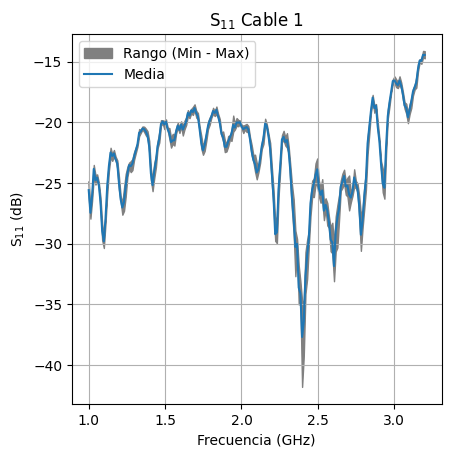

In [67]:
# Parte 2:
# Esta es la que hice primero, que debería borrarla.

import matplotlib.pyplot as plt
import numpy as np

cacharros = ["Cable_1", "Cable_2"]

f, S_11, S_21 = get_S_parameter(cacharros[0])

f = np.array(f)/10**9

S_11 = np.array(S_11)
S_11 = S_11.transpose()

S_11_mean = [sum(x) / len(x) for x in S_11]
S_11_max = [max(x) for x in S_11]
S_11_min = [min(x) for x in S_11]

plt.fill_between(f, 
                 S_11_min, 
                 S_11_max, 
                 color='gray', alpha=1, label='Rango (Min - Max)')
plt.plot(f, S_11_mean, label = "Media")

ax = plt.gca()
ax.set_xlabel("Frecuencia (GHz)")
ax.set_ylabel(r"S$_{11}$ (dB)")
ax.set_title(r"S$_{11}$ Cable 1")

plt.grid(True)
ax.set_box_aspect(1)
plt.legend()
plt.show()

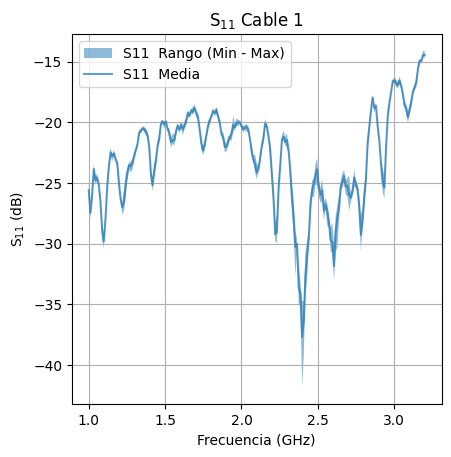

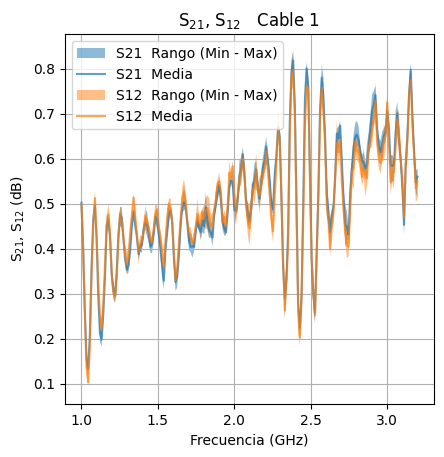

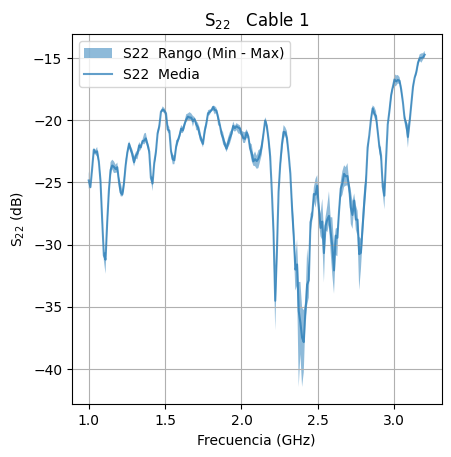

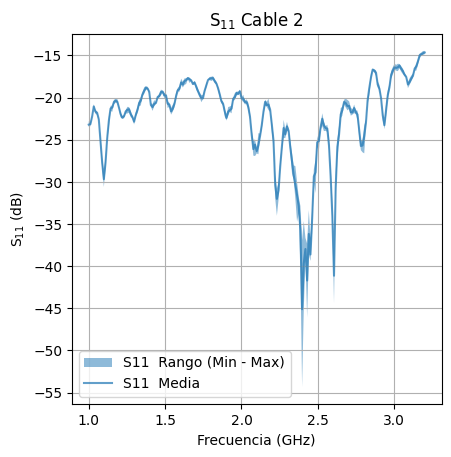

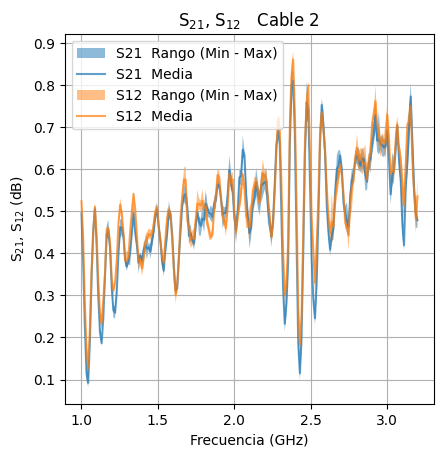

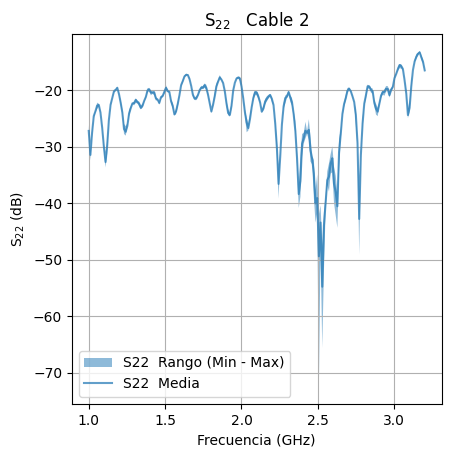

In [68]:
import matplotlib.pyplot as plt

cacharros = ["Cable_1", "Cable_2"]
cacharros_name = ["Cable 1", "Cable 2"]

for i, cacharro in enumerate(cacharros):
    f, S_11, S_21 = get_S_parameter(cacharro)
    set_plot(f, S_11, r"S11")

    ax = plt.gca()
    ax.set_ylabel(r"S$_{11}$ (dB)")
    ax.set_title(r"S$_{11}$ " + cacharros_name[i])
    plt.show()

    set_plot(f, S_21, r"S21")
    f, S_11, S_21 = get_S_parameter(cacharro, inv = 1)
    set_plot(f, S_21, r"S12")

    ax = plt.gca()
    ax.set_ylabel(r"S$_{21}$, S$_{12}$ (dB)")
    ax.set_title(r"S$_{21}$, S$_{12}$   " + cacharros_name[i])
    plt.show()


    set_plot(f, S_11, r"S22")

    ax = plt.gca()
    ax.set_ylabel(r"S$_{22}$ (dB)")
    ax.set_title(r"S$_{22}$   " + cacharros_name[i])
    plt.show()


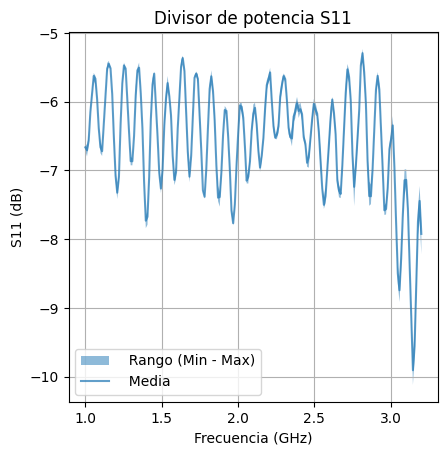

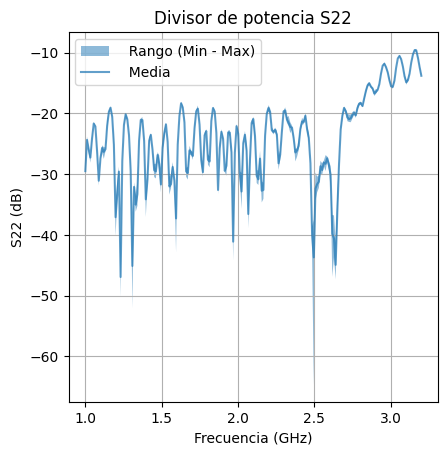

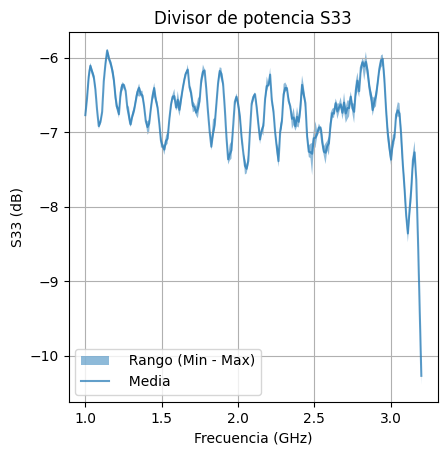

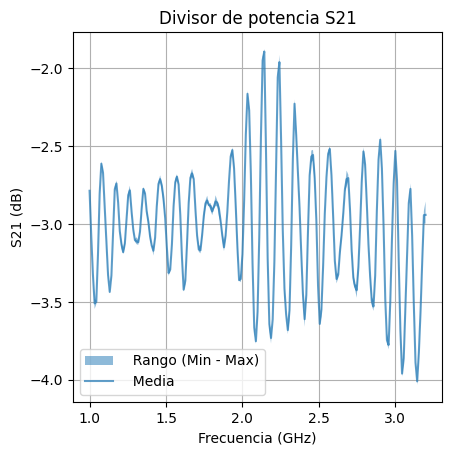

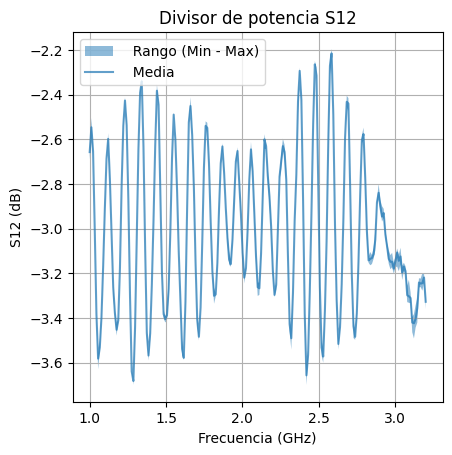

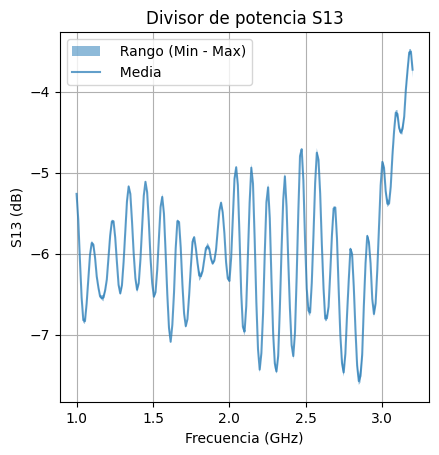

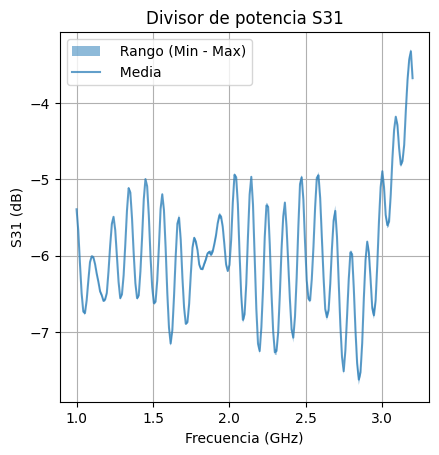

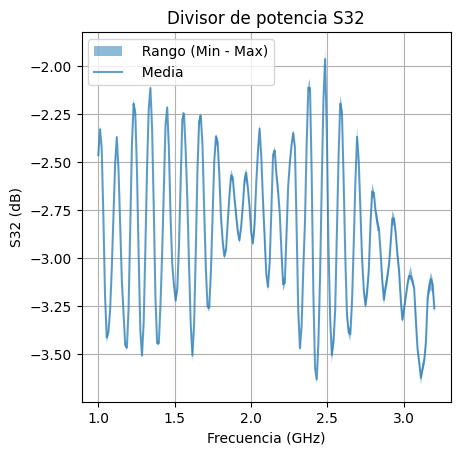

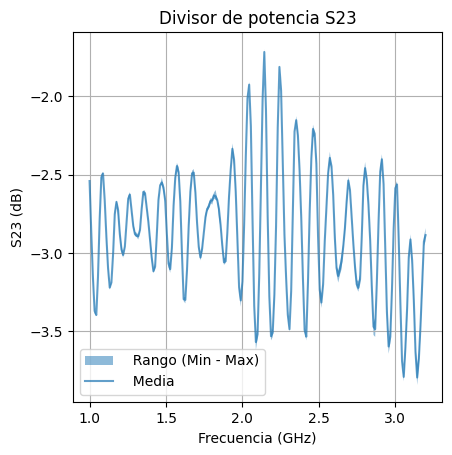

In [69]:
# Parte 3

# Parámetros de la diagonal
diagonal = ["S11_S21", "S22_S12", "S33_S13"]
for i, cacharro in enumerate(diagonal):
    f, S_11, S_21 = get_S_parameter(cacharro)
    set_plot(f, S_11, "")

    ax = plt.gca()
    ax.set_ylabel(rf"S{i+1}{i+1} (dB)")
    ax.set_title(rf"Divisor de potencia S{i+1}{i+1}")
    plt.show()

# Me equivoqué
"""
off_diag = ["S11_S21", "S22_S12", "S33_S13", "S11_S31", "S22_S32", "S33_S23"]
for i in range(3):
    f, S_11, S_21 = get_S_parameter(off_diag[2*i])
    set_plot(f, S_21, off_diag[2*i][-3:])

    f, S_11, S_21 = get_S_parameter(off_diag[2*i+1])
    set_plot(f, S_21, off_diag[2*i+1][-3:])

    ax = plt.gca()
    ax.set_ylabel(off_diag[2*i][-3:] + ", " + off_diag[2*i+1][-3:] + " (dB)")
    ax.set_title(rf"Divisor de potencia " + off_diag[2*i][-3:] + ", " + off_diag[2*i+1][-3:])

    plt.show()
"""
# Parámetros fuera de la diagonal.
off_diag = ["S11_S21", "S22_S12", "S33_S13", "S11_S31", "S22_S32", "S33_S23"]
for cacharro in off_diag:
    f, S_11, S_21 = get_S_parameter(cacharro)
    set_plot(f, S_21, "")

    ax = plt.gca()
    ax.set_ylabel(cacharro[-3:] + " (dB)")
    ax.set_title("Divisor de potencia " + cacharro[-3:])
    plt.show()



## Conclusiones y análisis

### Caracterización de las cargas

- ¿Cuál de las cargas empleadas en la práctica acopla mejor con la línea? ¿Por qué?
- ¿Qué valor tiene que tener la impedancia de dicha carga?
- Identifica el comportamiento de las líneas de transmisión coaxiales a partir de las medidas experimentales e indica si es el que esperabas.
- Identifica el comportamiento del divisor de potencia a partir de las medidas experimentales e indica si es el que esperabas. 

_Redacta aquí tus respuestas:_

### Parte 1: Elementos de un puerto

Observamos que para la carga 2 los valores del parámetro $S_{11}$ son muy pequeños (de orden menor a $10^{-30}$), por lo que podemos considerar que toda la onda emitida es absorbida por la carga, condición que se cumple cuando la carga está acoplada con la línea. En cambio, para la carga 1 el parámetro $S_{11}$ toma valores de orden comparable a la unidad.\\

Deducimos entonces que la carga 1 tiene una impedancia similar a la de la línea, es decir, 50 $\Omega$, y la carga 2 tendrá, probablemente, una impedancia cercana a 0 $\Omega$, pues una terminación en cortocircuito teóricamente refleja toda la onda.

### Parte 2: Elementos de dos puertos

En las gráficas correspondientes a los cables, podemos ver que el comportamiento de los parámetros $S_{21}$ y $S_{12}$ es el mismo. Lo mismo sucede para los parámetros $S_{11}$ y $S_{22}$. Esto es de esperar debido a que el cable es simétrico, de forma que es indistinto cuál de los puertos del cable llamamos 1 y 2.\\

Además, se puede comprobar que los valores de los parámetros son los mismos para cada cable, con lo que concluimos que dichos cables son idénticos.

### Parte 3: Elementos de tres puertos

